In [2]:
%load_ext autoreload
%autoreload 2

from qs_mps.mps_class import MPS
from qs_mps.utils import tensor_shapes, create_sequential_colors, von_neumann_entropy
import numpy as np

import matplotlib.pyplot as plt

# default parameters of the plot layout
plt.rcParams["text.usetex"] = True  # use latex
plt.rcParams["font.size"] = 13
plt.rcParams["figure.dpi"] = 300
plt.rcParams["figure.constrained_layout.use"] = True

In [ ]:
def get_gs(kwargs):
    mps_chain = MPS(L=kwargs.get("L"),
                            d=kwargs.get("d"),
                            model=kwargs.get("model"),
                            chi=kwargs.get("chi"),
                            J=kwargs.get("Jz"),
                            h=kwargs.get("J_perp"),
                            k=(kwargs.get("t"),kwargs.get("tp")) ,
                            eps=kwargs.get("eps")) 
    mps_chain.load_sites(path=kwargs.get("path"), precision=kwargs.get("precision"))
    return mps_chain

In [ ]:
Ls = [3,5,7,9,11,13,15,17]
chis = [150,200,250]
path = "D:work/projects/6_TJ"
for l in Ls:
    for chi in chis:
        args = dict(L=l, d=3, model="tj", chi=chi, Jz=10, J_perp=2, t=2, tp=2, eps=0, path=path, precision=3)
        mps_chain = get_gs(args)
        mps_chain.canonical_form()
        print(von_neumann_entropy(mps_chain.bonds[l//2]))

In [ ]:
loc_mag = []
for i in range(1,mps_chain.L+1):
    mps_chain.local_param(site=i, op="Z")
    loc_mag.append(mps_chain.mpo_first_moment().real)
locs = [(i, loc) for i, loc in enumerate(loc_mag)]

In [ ]:
locs[(l//2-1):(l//2+3)]

In [ ]:
L = 48
mps_expanded = MPS(L=L, d=3, model="tj", chi=chi, J=10, h=2, k=(2,2), eps=0)
block_mps = MPS(L=4, d=3, model="tj", chi=chi, J=10, h=2, k=(2,2), eps=0)

block_mps.sites = mps_chain.sites[(l//2-1):(l//2+3)].copy()
# tensor_shapes(block_mps.sites)

mps_expanded.sites = block_mps.sites * (L//4)
mps_chain.enlarge_chi(noise_std=1e-7)
mps_expanded.sites = mps_chain.sites[0] + mps_expanded.sites + mps_chain.sites[-1]
mps_expanded.L = len(mps_expanded.sites)
tensor_shapes(mps_expanded.sites)
mps_expanded.canonical_form()

print(mps_expanded._compute_norm())

loc_mag = []
for i in range(1,mps_expanded.L+1):
    mps_expanded.local_param(site=i, op="Z")
    loc_mag.append(mps_expanded.mpo_first_moment().real)
loc_mag

In [74]:
from qs_mps.mps_class import MPS
L = 20
d = 3
Jz = -1/2
J_perp = 1
t = -0.1
tp = -0.1
V = 0.5
model = "tj"
chis = [20,40,60,80]
chis = [30]
eps = 2
path = "D:/work/projects/6_TJ"
hole_tn = np.array([[[0],[1],[0]]])
up_tn = np.array([[[1],[0],[0]]])
down_tn = np.array([[[0],[0],[1]]])
number_of_holes = 2
rng = np.random.default_rng()
defect_sites = rng.choice(L, size=number_of_holes, replace=False)
defect_sites = [L//2-1, L//2]
print(defect_sites)
precision = 3
hole_occup = []
spin_occup = []
for chi in chis:
    mps_chain = MPS(L=L,d=d,model=model,chi=chi,J=Jz,h=V,k=(t,tp),eps=eps)
    mps_chain._random_state(301)
    for i in range(L):
        # if (i % 2) == 0:
        #     mps_chain.sites[i] = up_tn.copy()
        # elif (i % 2) == 1:
        #     mps_chain.sites[i] = down_tn.copy()
        mps_chain.sites[i] = up_tn.copy()

    mps_chain.enlarge_chi(noise_std=1e-6)
    mps_chain.canonical_form()
    # for i in range(L):
    #     mps_chain.sites[i] = hole_tn.copy()
    # mps_chain.enlarge_chi(noise_std=1e-6)
    # mps_chain.canonical_form()
    # # tensor_shapes(mps_chain.sites)
    # print("------------before----------------")
    # mps_chain.order_param(op="nh")
    # print(mps_chain.mpo_first_moment())
    # mps_chain.w = None
    mps_chain.DMRG(trunc_tol=False, trunc_chi=True, n_sweep=10, defect=True, defect_sites=defect_sites)
    hole_occup_chi = []
    for i in range(1,mps_chain.L+1):
        mps_chain.local_param(site=i, op="nh")
        hole_occup_chi.append(mps_chain.mpo_first_moment().real)
    spin_occup_chi = []
    for i in range(1,mps_chain.L+1):
        mps_chain.local_param(site=i, op="Z")
        spin_occup_chi.append(mps_chain.mpo_first_moment().real)
    print("------------after----------------")
    mps_chain.order_param(op="nh")
    print("holes", mps_chain.mpo_first_moment())
    mps_chain.order_param(op="Z")
    print("mag", mps_chain.mpo_first_moment())
    hole_occup.append(hole_occup_chi)
    spin_occup.append(spin_occup_chi)

[9, 10]
------------after----------------
holes (2.0411836876311384+1.2122798049543006e-16j)
mag (1.1249531664948837+3.25851757737685e-17j)


<>:4: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
<>:4: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
C:\Users\HP\AppData\Local\Temp\ipykernel_4996\71960941.py:4: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
  plt.plot(occup, color=colors[i], label=f"$\chi={chis[i]}$")


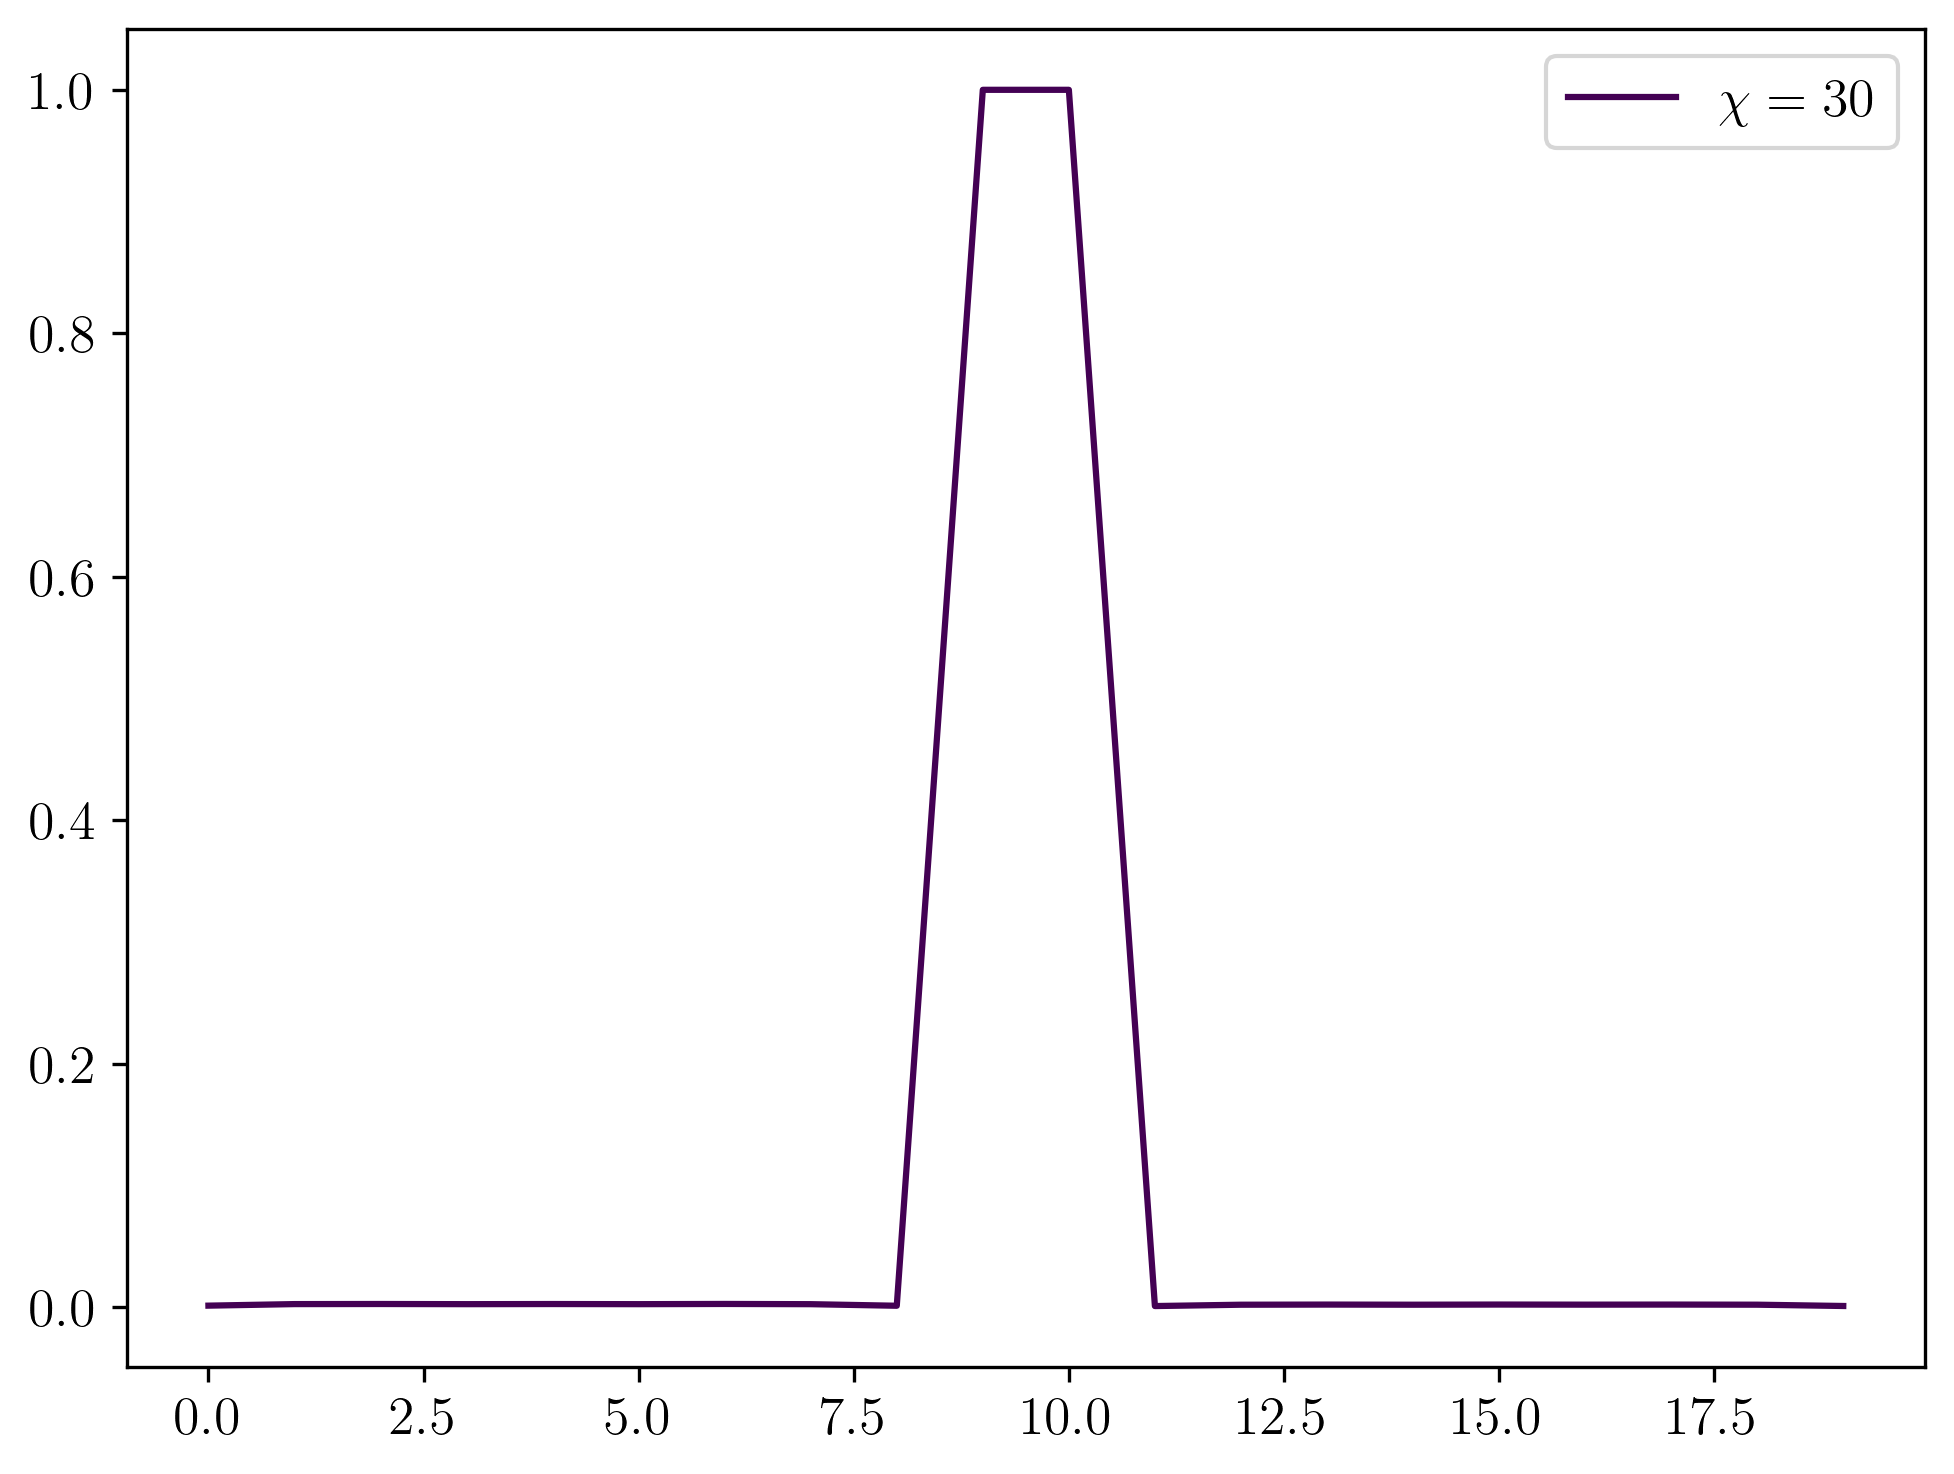

In [75]:
colors = create_sequential_colors(num_colors=len(chis))

for i, occup in enumerate(hole_occup):
    plt.plot(occup, color=colors[i], label=f"$\chi={chis[i]}$")
plt.legend()

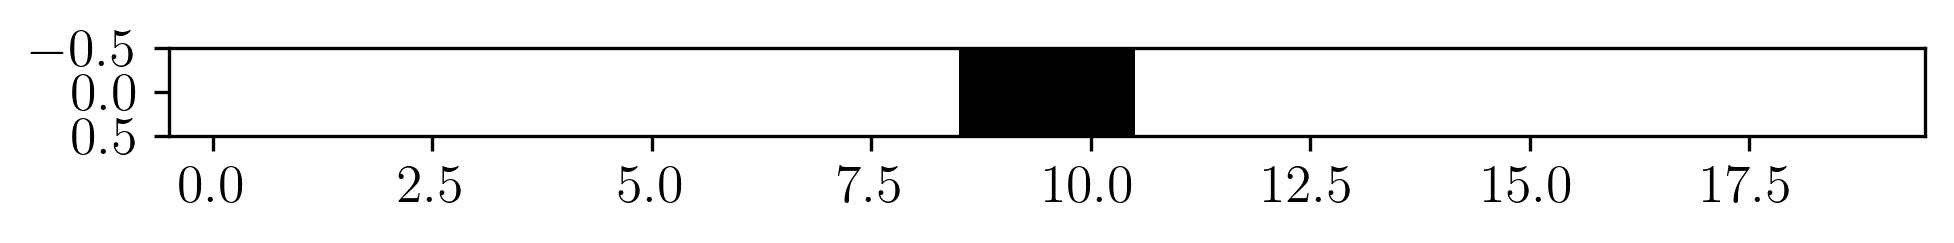

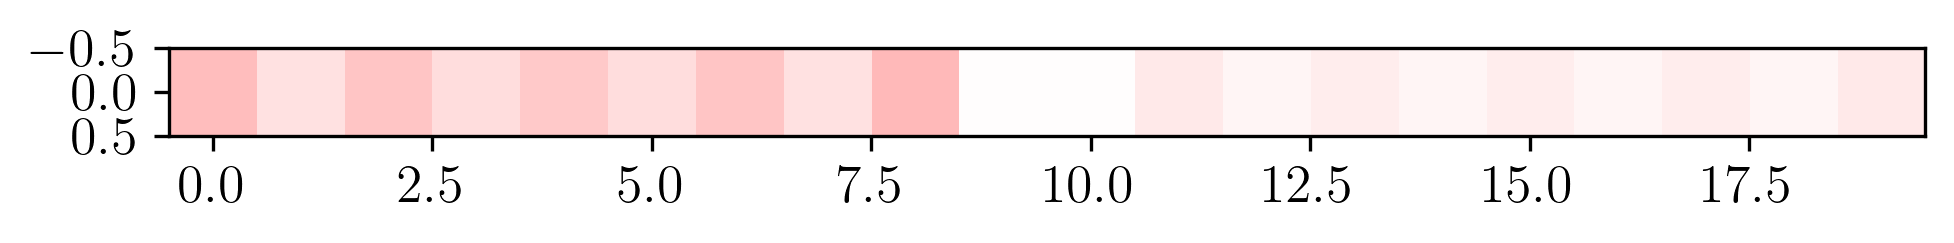

In [76]:
plt.imshow(np.asarray(hole_occup[-1]).reshape((1,L)), cmap="Greys", vmin=0, vmax=1)
plt.show()
plt.imshow(np.asarray(spin_occup[-1]).reshape((1,L)), cmap="seismic", vmin=-1, vmax=1)

In [77]:
for i in range(mps_chain.L):
    mps_chain.local_param(site=i, op="c")
    print(i, mps_chain.mpo_first_moment().real)

0 0.0
1 1.0000000000000027
2 1.0000000000000027
3 1.0000000000000027
4 1.0000000000000027
5 1.0000000000000027
6 1.0000000000000027
7 1.0000000000000027
8 1.0000000000000027
9 1.0000000000000027
10 1.0000000000000027
11 1.0000000000000027
12 1.0000000000000027
13 1.0000000000000027
14 1.0000000000000027
15 1.0000000000000027
16 1.0000000000000027
17 1.0000000000000027
18 1.0000000000000027
19 1.0000000000000027


In [82]:
from qs_mps.mps_class import MPS
from tqdm import tqdm

L = 20
d = 3
Jz = -1/2
J_perp = 1
t = -0.1
tp = -0.1
V = 0.5
model = "tj"
chis = [20,40,60,80]
chis = [30]
eps = 2
path = "D:/work/projects/6_TJ"
hole_tn = np.array([[[0],[1],[0]]])
up_tn = np.array([[[1],[0],[0]]])
down_tn = np.array([[[0],[0],[1]]])
number_of_holes = 2
rng = np.random.default_rng()
defect_sites = rng.choice(L, size=number_of_holes, replace=False)
params = np.linspace(-4,4,20), np.linspace(-4,4,20)
params = map(lambda m: m.flatten(), np.meshgrid(*params, indexing='xy'))
params = np.stack(tuple(params)).T

defect_sites = [L//2-1, L//2]

precision = 3
hole_occup = []
spin_occup = []
pbar = tqdm(params, dynamic_ncols=True)
for t, V in pbar:
    mps_chain = MPS(L=L,d=d,model=model,chi=chi,J=Jz,h=V,k=(t,t),eps=eps)
    mps_chain._random_state(301)
    for i in range(L):
        # if (i % 2) == 0:
        #     mps_chain.sites[i] = up_tn.copy()
        # elif (i % 2) == 1:
        #     mps_chain.sites[i] = down_tn.copy()
        mps_chain.sites[i] = up_tn.copy()

    mps_chain.enlarge_chi(noise_std=1e-6)
    mps_chain.canonical_form()
    # for i in range(L):
    #     mps_chain.sites[i] = hole_tn.copy()
    # mps_chain.enlarge_chi(noise_std=1e-6)
    # mps_chain.canonical_form()
    # # tensor_shapes(mps_chain.sites)
    # print("------------before----------------")
    # mps_chain.order_param(op="nh")
    # print(mps_chain.mpo_first_moment())
    # mps_chain.w = None
    mps_chain.DMRG(trunc_tol=False, trunc_chi=True, n_sweep=10, defect=True, defect_sites=defect_sites)
    hole_occup_chi = []
    for i in range(1,mps_chain.L+1):
        mps_chain.local_param(site=i, op="nh")
        hole_occup_chi.append(mps_chain.mpo_first_moment().real)
    spin_occup_chi = []
    for i in range(1,mps_chain.L+1):
        mps_chain.local_param(site=i, op="Z")
        spin_occup_chi.append(mps_chain.mpo_first_moment().real)
    hole_occup.append(hole_occup_chi)
    spin_occup.append(spin_occup_chi)

  0%|          | 0/400 [00:00<?, ?it/s]C:\Users\HP\Desktop\qs-mps\src\qs_mps\mps_class.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  from qs_mps.utils import *
C:\Users\HP\Desktop\qs-mps\src\qs_mps\mps_class.py:20: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  U_evolution_sparse,
C:\Users\HP\Desktop\qs-mps\src\qs_mps\mps_class.py:16: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the 

ValueError: could not broadcast input array from shape (816,) into shape (17,3,16)

In [88]:
i = 0
occup_matrix = np.zeros(20*15)
for t, V in pbar:
    occup_matrix[i] = np.sum(hole_occup[i])
    i += 1

IndexError: index 300 is out of bounds for axis 0 with size 300

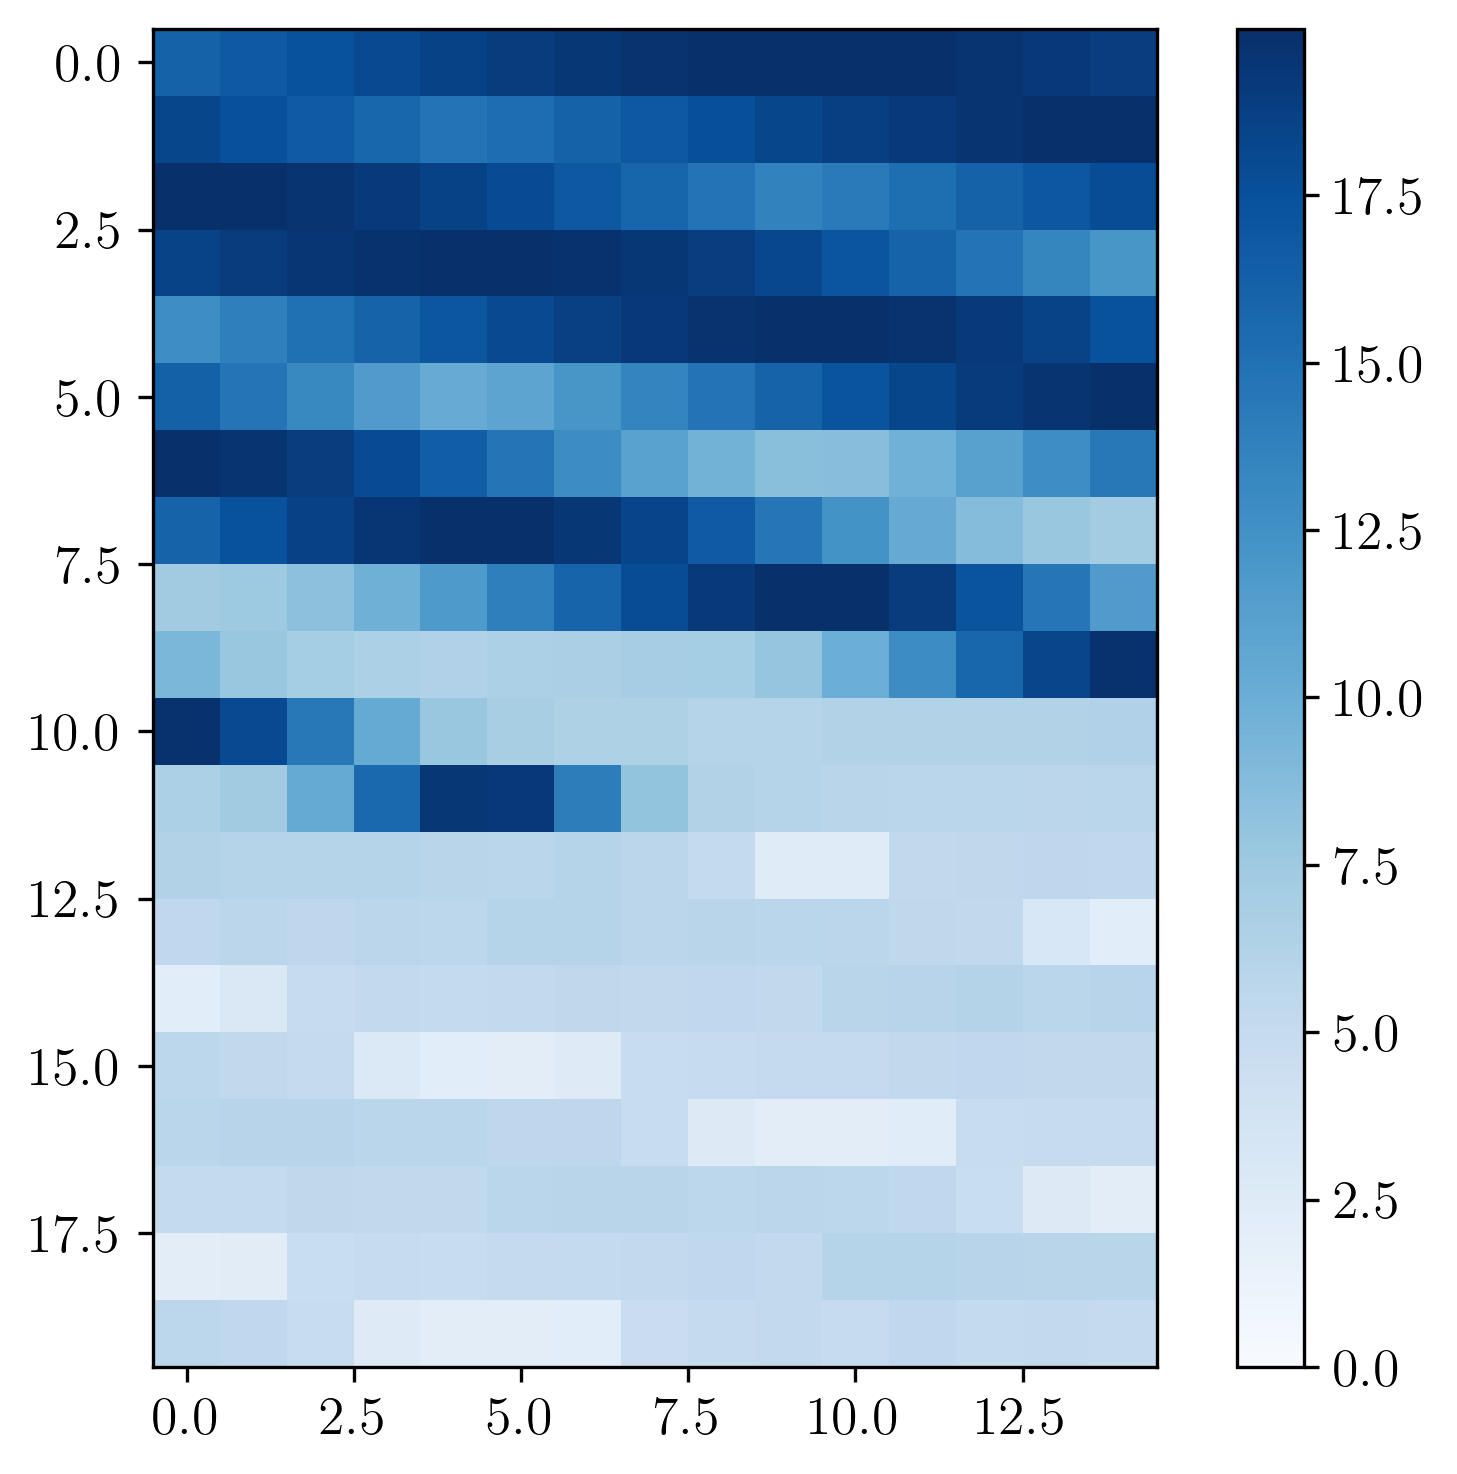

In [90]:
occup_matrix = occup_matrix.reshape((20,15))

plt.imshow(occup_matrix, cmap="Blues", vmin=0)
plt.colorbar()

In [91]:
i = 0
mag_matrix = np.zeros(20*15)
for t, V in pbar:
    mag_matrix[i] = np.sum(spin_occup[i])
    i += 1

IndexError: index 300 is out of bounds for axis 0 with size 300

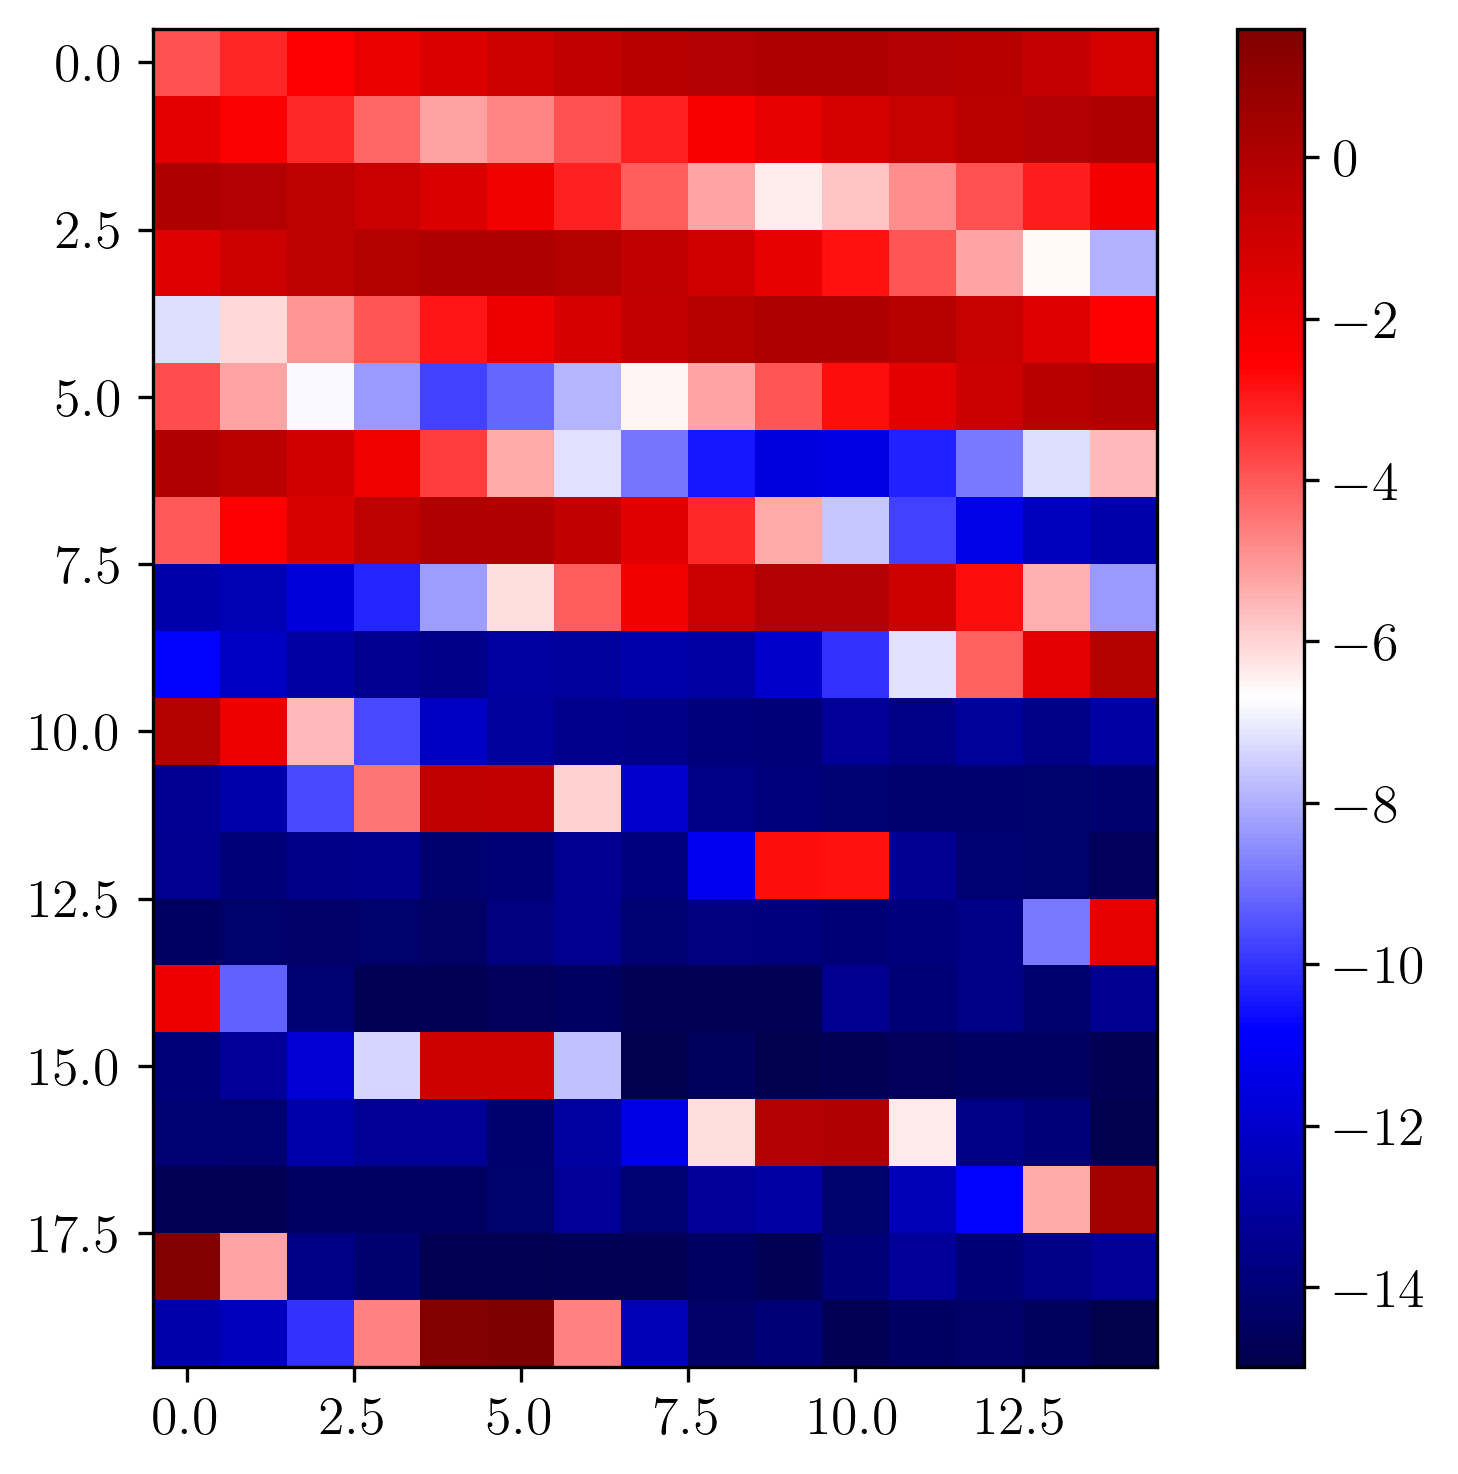

In [93]:
mag_matrix = mag_matrix.reshape((20,15))

plt.imshow(mag_matrix, cmap="seismic")
plt.colorbar()